In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications.densenet import preprocess_input


import kagglehub
# CHANGE THIS LINE for each notebook
from tensorflow.keras.applications import DenseNet121

LOADING THE DATASET

In [ ]:
path = kagglehub.dataset_download("omkarmanohardalvi/lungs-disease-dataset-4-types")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lungs-disease-dataset-4-types' dataset.
Path to dataset files: /kaggle/input/lungs-disease-dataset-4-types


IMAGE PREPROCESSING

In [ ]:


dataset_path = "/root/.cache/kagglehub/datasets/omkarmanohardalvi/lungs-disease-dataset-4-types/versions/1/Lung Disease Dataset"

print(os.listdir(dataset_path))

# Training data (with augmentation)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation + Test data (NO augmentation, but SAME preprocessing)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

['val', 'test', 'train']


LOADING TRAIN TEST VAL DATA

In [ ]:
train_generator = train_datagen.flow_from_directory(
    dataset_path + "/train",
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical'
)

Found 6054 images belonging to 5 classes.


In [ ]:
val_generator = test_datagen.flow_from_directory(
    dataset_path + "/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 2016 images belonging to 5 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(
    dataset_path + "/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2025 images belonging to 5 classes.


In [ ]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
for layer in base_model.layers[-50:]:
    layer.trainable = True

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 184s 820ms/step - accuracy: 0.6947 - loss: 0.7611 - val_accuracy: 0.7941 - val_loss: 0.5050
Epoch 2/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 129s 679ms/step - accuracy: 0.7767 - loss: 0.5368 - val_accuracy: 0.8041 - val_loss: 0.4748
Epoch 3/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 131s 688ms/step - accuracy: 0.7950 - loss: 0.4928 - val_accuracy: 0.8304 - val_loss: 0.4266
Epoch 4/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 131s 692ms/step - accuracy: 0.8043 - loss: 0.4623 - val_accuracy: 0.8244 - val_loss: 0.4233
Epoch 5/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 131s 688ms/step - accuracy: 0.8029 - loss: 0.4605 - val_accuracy: 0.8041 - val_loss: 0.4456
Epoch 6/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 130s 687ms/step - accuracy: 0.8188 - loss: 0.4375 - val_accuracy: 0.8388 - val_loss: 0.4086
Epoch 7/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 130s 686ms/step - accuracy: 0.8155 - loss: 0.4235 - val_accuracy: 0.8378 - val_loss: 0.3910
Epoch 8/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 134s 705ms/step - accuracy: 0.8204 -

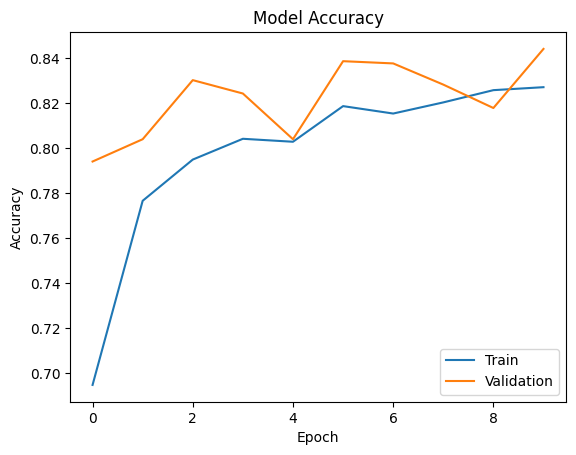

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()

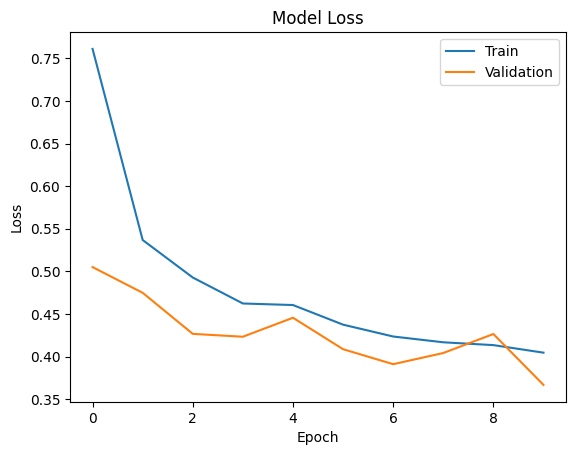

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

64/64 ━━━━━━━━━━━━━━━━━━━━ 72s 699ms/step


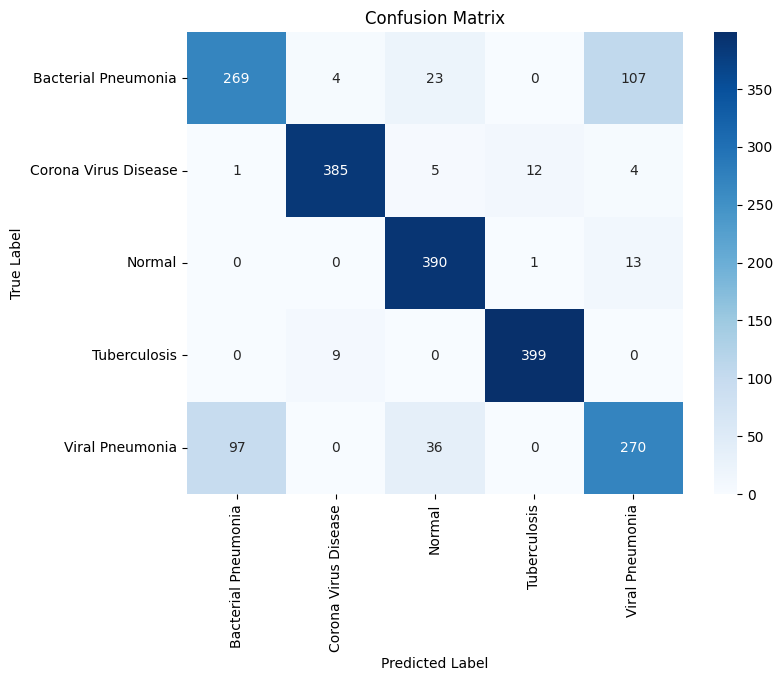

In [ ]:
# Get predictions
predictions = model.predict(test_generator)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)
precision = precision_score(y_true, y_pred, average='weighted')
print("Precision:", precision)
recall = recall_score(y_true, y_pred, average='weighted')
print("Recall:", recall)
f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score:", f1)
print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

Accuracy: 0.845925925925926
Precision: 0.8431778447229868
Recall: 0.845925925925926
F1 Score: 0.8435833533395803
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.73      0.67      0.70       403
Corona Virus Disease       0.97      0.95      0.96       407
              Normal       0.86      0.97      0.91       404
        Tuberculosis       0.97      0.98      0.97       408
     Viral Pneumonia       0.69      0.67      0.68       403

            accuracy                           0.85      2025
           macro avg       0.84      0.85      0.84      2025
        weighted avg       0.84      0.85      0.84      2025

